# Phase 3: Classification and Evaluation

**Purpose:** Train and evaluate binary classifiers for `over_budget` and `late` targets using four feature configurations with SMOTE for class imbalance.

**Inputs:**
- `data/processed/labeled_contracts.csv` — Structured features
- `data/processed/doc_topic_matrix.parquet` — LDA topic features
- `data/processed/tfidf_matrix.npz` — TF-IDF features

**Outputs:**
- `models/*.pkl` — 16 trained models (2 targets × 4 configs × 2 algorithms)
- `data/processed/results_comparison.csv` — Performance comparison table
- `figures/roc_*.png` — ROC curves
- `figures/confusion_matrix_best.png` — Best model confusion matrices
- `figures/feature_importance.png` — Random forest feature importance

**Model Grid:**
| Target | Config | Description | Algorithms |
|--------|--------|-------------|------------|
| over_budget | A | Structured only | LogReg, RF |
| over_budget | B | TF-IDF only | LogReg, RF |
| over_budget | C | LDA topics only | LogReg, RF |
| over_budget | D | Combined (all) | LogReg, RF |
| late | A-D | (same configs) | LogReg, RF |

In [1]:
## 0. Install Required Package (if missing)
import sys
import subprocess

try:
    import imblearn
except ImportError:
    print('Installing imbalanced-learn...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn'])
    import imblearn
    print('imbalanced-learn installed successfully!')
else:
    print('imbalanced-learn already available.')

imbalanced-learn already available.


## 1. Environment Setup and Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import warnings
import os
import joblib
from pathlib import Path

# ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, f1_score, 
                             precision_recall_curve, average_precision_score)

# SMOTE for class imbalance
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

RANDOM_STATE = 42

print('Environment configured.')

Environment configured.


## 2. Configuration

In [3]:
# --- File Paths ---
LABELED_DATA = '../data/processed/labeled_contracts.csv'
DOC_TOPIC_PATH = '../data/processed/doc_topic_matrix.parquet'
TFIDF_MATRIX_PATH = '../data/processed/tfidf_matrix.npz'
TFIDF_FEATURES_PATH = '../data/processed/tfidf_features.txt'

MODELS_DIR = '../models'
RESULTS_PATH = '../data/processed/results_comparison.csv'
FIGURES_DIR = '../figures'

# Create directories
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# --- Modeling Configuration ---
TEST_SIZE = 0.20
SMOTE_THRESHOLD = 0.10  # Apply SMOTE if minority class < 10%

# Feature configs
CONFIGS = {
    'A': 'structured_only',
    'B': 'tfidf_only', 
    'C': 'lda_only',
    'D': 'combined'
}

# Targets
TARGETS = ['over_budget', 'late']

print('Configuration loaded.')

Configuration loaded.


## 3. Load Data and Features

In [4]:
# Load labeled dataset
print('Loading labeled dataset...')
df = pd.read_csv(LABELED_DATA)
print(f'Loaded: {len(df):,} rows x {len(df.columns)} columns')

# Load document-topic matrix (LDA features)
print('\nLoading LDA topic features...')
topic_df = pd.read_parquet(DOC_TOPIC_PATH)
topic_cols = [c for c in topic_df.columns if c.startswith('topic_')]
print(f'  LDA topics: {len(topic_cols)} (from {len(topic_df):,} docs)')

# Load TF-IDF matrix
print('\nLoading TF-IDF features...')
tfidf_matrix_raw = sparse.load_npz(TFIDF_MATRIX_PATH)

# Load TF-IDF corpus PIIDs and align to full df (fixes B2/B3)
TFIDF_PIIDS_PATH = '../data/processed/tfidf_corpus_piids.txt'
with open(TFIDF_PIIDS_PATH, 'r', encoding='utf-8') as f:
    tfidf_corpus_piids = [line.strip() for line in f if line.strip()]

# Build DataFrame indexed by PIID
tfidf_df_raw = pd.DataFrame.sparse.from_spmatrix(
    tfidf_matrix_raw,
    columns=[f'tfidf_{i}' for i in range(tfidf_matrix_raw.shape[1])],
    index=tfidf_corpus_piids
)

# Reindex to match full df PIIDs (missing -> 0, not NaN)
df_piids = df['piid'].astype(str).values
tfidf_aligned = tfidf_df_raw.reindex(df_piids, fill_value=0)
tfidf_aligned.index = df.index

# Convert back to sparse matrix for downstream use
from scipy.sparse import csr_matrix
tfidf_matrix = csr_matrix(tfidf_aligned.sparse.to_coo())
print(f'TF-IDF matrix aligned to df: {tfidf_matrix.shape} (was {tfidf_matrix_raw.shape})')
with open(TFIDF_FEATURES_PATH, 'r') as f:
    tfidf_features = f.read().strip().split('\n')
print(f'  TF-IDF shape: {tfidf_matrix.shape}')
print(f'  TF-IDF features: {len(tfidf_features)}')

# Check target availability
for target in TARGETS:
    if target in df.columns:
        pos = df[target].sum()
        print(f'\nTarget {target}: {pos:,} positive ({pos/len(df)*100:.2f}%)')
    else:
        print(f'\nWARNING: Target {target} not found in dataset')

Loading labeled dataset...
Loaded: 45,456 rows x 18 columns

Loading LDA topic features...


  LDA topics: 18 (from 9,357 docs)

Loading TF-IDF features...


TF-IDF matrix aligned to df: (45456, 500) (was (45418, 500))
  TF-IDF shape: (45456, 500)
  TF-IDF features: 500

Target over_budget: 4,725 positive (10.39%)

Target late: 27,961 positive (61.51%)


## 4. Define Feature Matrix Builders

In [5]:
import pandas as pd
import numpy as np


def _signed_log(x):
    """Signed log transform: sign(x) * log1p(|x|). Handles negatives safely."""
    x = pd.to_numeric(x, errors="coerce").fillna(0)
    return np.sign(x) * np.log1p(np.abs(x))


def get_structured_features(df):
    """
    Extract structured features per data_dictionary.md (Section 3).

    Features:
      - log_base_value   : signed log of initial contract value
      - num_modifications: count of modifications
      - num_offers_imputed: num_offers with median imputation
      - contract_type_*  : one-hot of contract pricing type
      - extent_competed_*: one-hot of competition level
      - psc_category_*   : one-hot of PSC first char (Y/Z/numeric groups)

    NOTE: Does NOT include log_final_value (leaks cost_growth_pct/over_budget).
    """
    features = pd.DataFrame(index=df.index)

    # 1. log_base_value (safe: from initial award)
    if "base_value" in df.columns:
        features["log_base_value"] = _signed_log(df["base_value"])
    elif "log_initial_cost" in df.columns:
        features["log_base_value"] = df["log_initial_cost"].fillna(0)

    # 2. num_modifications
    if "num_modifications" in df.columns:
        features["num_modifications"] = pd.to_numeric(df["num_modifications"], errors="coerce").fillna(1)

    # 3. num_offers_imputed (median imputation)
    if "num_offers" in df.columns:
        num_offers = pd.to_numeric(df["num_offers"], errors="coerce")
        features["num_offers_imputed"] = num_offers.fillna(num_offers.median())

    # 4. contract_type one-hot
    if "contract_type" in df.columns:
        ct = df["contract_type"].fillna("UNKNOWN").astype(str)
        # Keep top 10 categories, group rest as OTHER to prevent explosion
        top_ct = ct.value_counts().head(10).index
        ct_grouped = ct.where(ct.isin(top_ct), "OTHER")
        ct_dummies = pd.get_dummies(ct_grouped, prefix="contract_type", dtype=int)
        features = pd.concat([features, ct_dummies], axis=1)

    # 5. extent_competed one-hot
    if "extent_competed" in df.columns:
        ec = df["extent_competed"].fillna("UNKNOWN").astype(str)
        top_ec = ec.value_counts().head(8).index
        ec_grouped = ec.where(ec.isin(top_ec), "OTHER")
        ec_dummies = pd.get_dummies(ec_grouped, prefix="extent_competed", dtype=int)
        features = pd.concat([features, ec_dummies], axis=1)

    # 6. psc_category one-hot (first character grouping)
    if "psc" in df.columns:
        psc = df["psc"].fillna("X").astype(str).str.strip().str.upper()
        def psc_cat(p):
            if not p or p == "X":
                return "UNKNOWN"
            c = p[0]
            if c == "Y":
                return "CONSTRUCTION"
            if c == "Z":
                return "MAINTENANCE"
            if c.isdigit():
                return "SUPPLIES"
            return "OTHER"
        psc_cats = psc.apply(psc_cat)
        psc_dummies = pd.get_dummies(psc_cats, prefix="psc_category", dtype=int)
        features = pd.concat([features, psc_dummies], axis=1)

    # Final safety: fill any residual NaN with 0
    features = features.fillna(0)
    # Ensure all numeric
    for col in features.columns:
        features[col] = pd.to_numeric(features[col], errors="coerce").fillna(0)

    return features


def build_feature_matrix(config, df, topic_df, tfidf_matrix):
    """
    Build feature matrix for given configuration.

    Note: tfidf_matrix is expected to be pre-aligned to df rows (one row per PIID)
    via the alignment step in the data loading cell. This fixes B2/B3 bugs.
    """
    if config == "A":  # Structured only
        X = get_structured_features(df)
        feature_names = list(X.columns)

    elif config == "B":  # TF-IDF only (pre-aligned to df)
        tfidf_df = pd.DataFrame.sparse.from_spmatrix(
            tfidf_matrix,
            columns=[f"tfidf_{j}" for j in range(tfidf_matrix.shape[1])]
        )
        tfidf_df.index = df.index
        X = tfidf_df
        feature_names = list(X.columns)

    elif config == "C":  # LDA only
        merged = df.merge(topic_df[["piid"] + topic_cols], on="piid", how="left")
        X = merged[topic_cols].fillna(0)
        X.index = df.index
        feature_names = topic_cols

    elif config == "D":  # Combined (all features aligned to df)
        X_struct = get_structured_features(df)

        merged = df.merge(topic_df[["piid"] + topic_cols], on="piid", how="left")
        X_lda = merged[topic_cols].fillna(0)
        X_lda.index = df.index

        X_tfidf = pd.DataFrame.sparse.from_spmatrix(
            tfidf_matrix,
            columns=[f"tfidf_{j}" for j in range(tfidf_matrix.shape[1])]
        )
        X_tfidf.index = df.index

        X = pd.concat([X_struct, X_lda, X_tfidf], axis=1)
        X = X.fillna(0)
        feature_names = list(X.columns)

    return X, feature_names


print("Feature matrix builders defined (proper one-hot encoding, B2/B3 fixes).")


Feature matrix builders defined (proper one-hot encoding, B2/B3 fixes).


## 5. Train-Test Split

In [6]:
def prepare_data(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE):
    """Prepare train-test split with SMOTE if needed."""
    # Initial split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, 
        stratify=y
    )
    
    # Check if SMOTE needed
    minority_pct = min(y_train.mean(), 1 - y_train.mean())
    smote_applied = False
    
    if minority_pct < SMOTE_THRESHOLD:
        print(f'  Applying SMOTE (minority class: {minority_pct:.1%})')
        smote = SMOTE(random_state=random_state)
        X_train, y_train = smote.fit_resample(X_train, y_train)
        smote_applied = True
    else:
        print(f'  No SMOTE needed (minority class: {minority_pct:.1%})')
    
    return X_train, X_test, y_train, y_test, smote_applied


print('Data preparation function defined.')

Data preparation function defined.


## 6. Model Training and Evaluation

In [7]:
def train_and_evaluate(X_train, X_test, y_train, y_test, 
                        target_name, config_name, algorithm):
    """Train model and return metrics."""
    
    # Initialize model
    if algorithm == 'LogisticRegression':
        model = LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    else:  # RandomForest
        model = RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    from sklearn.metrics import precision_score, recall_score
    
    metrics = {
        'target': target_name,
        'config': config_name,
        'algorithm': algorithm,
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'auc': roc_auc_score(y_test, y_proba),
        'avg_precision': average_precision_score(y_test, y_proba),
        'n_train': X_train.shape[0],
        'n_test': X_test.shape[0],
        'n_pos_train': int(y_train.sum()),
        'n_pos_test': int(y_test.sum())
    }
    
    return model, metrics, y_proba


print('Training function defined.')

Training function defined.


## 7. Run 16-Model Grid

In [8]:
# Store all results
all_results = []
trained_models = {}
roc_data = {}

print('=' * 70)
print('TRAINING 16-MODEL GRID')
print('=' * 70)

for target in TARGETS:
    print(f'\n\nTARGET: {target.upper()}')
    print('-' * 70)
    
    y = df[target].values
    
    for config_code, config_name in CONFIGS.items():
        print(f'\n  Config {config_code}: {config_name}')
        
        # Build feature matrix
        X, feature_names = build_feature_matrix(config_code, df, topic_df, tfidf_matrix)
        
        # Align y with X (handling potential mismatches from feature sources)
        if X.shape[0] != len(y):
            print(f'    WARNING: Feature/target length mismatch ({X.shape[0]} vs {len(y)})')
            continue
        
        # Prepare data with SMOTE
        try:
            X_train, X_test, y_train, y_test, smote_applied = prepare_data(X, y)
        except Exception as e:
            print(f'    ERROR in data preparation: {e}')
            continue
        
        # Scale features for Logistic Regression
        # Use with_mean=False for sparse matrices (TF-IDF)
        import scipy.sparse as sp
        is_sparse = sp.issparse(X_train) or (hasattr(X_train, 'sparse') and any(isinstance(dt, pd.SparseDtype) for dt in X_train.dtypes))
        scaler = StandardScaler(with_mean=not is_sparse)
        # Convert sparse DataFrame to sparse matrix for scaling
        if hasattr(X_train, 'sparse'):
            try:
                X_train_input = X_train.sparse.to_coo().tocsr()
                X_test_input = X_test.sparse.to_coo().tocsr()
            except AttributeError:
                X_train_input = X_train
                X_test_input = X_test
        else:
            X_train_input = X_train
            X_test_input = X_test
        X_train_scaled = scaler.fit_transform(X_train_input)
        X_test_scaled = scaler.transform(X_test_input)
        
        # Train both algorithms
        for algorithm in ['LogisticRegression', 'RandomForest']:
            print(f'    Training {algorithm}...')
            
            # Use scaled data for LogReg, original for RF
            X_tr = X_train_scaled if algorithm == 'LogisticRegression' else X_train
            X_te = X_test_scaled if algorithm == 'LogisticRegression' else X_test
            
            try:
                model, metrics, y_proba = train_and_evaluate(
                    X_tr, X_te, y_train, y_test,
                    target, config_code, algorithm
                )
                
                metrics['smote_applied'] = smote_applied
                all_results.append(metrics)
                
                # Store model
                model_key = f'{target}_{config_code}_{algorithm}'
                trained_models[model_key] = {
                    'model': model,
                    'scaler': scaler if algorithm == 'LogisticRegression' else None,
                    'feature_names': feature_names,
                    'config': config_code,
                    'target': target
                }
                
                # Store ROC data
                fpr, tpr, _ = roc_curve(y_test, y_proba)
                roc_data[model_key] = {'fpr': fpr, 'tpr': tpr, 'auc': metrics['auc']}
                
                print(f'      F1: {metrics["f1"]:.3f}, AUC: {metrics["auc"]:.3f}')
                
            except Exception as e:
                print(f'    ERROR training {algorithm}: {e}')
                continue

print('\n' + '=' * 70)
print('Training complete!')

TRAINING 16-MODEL GRID


TARGET: OVER_BUDGET
----------------------------------------------------------------------

  Config A: structured_only
  No SMOTE needed (minority class: 10.4%)
    Training LogisticRegression...
      F1: 0.298, AUC: 0.730
    Training RandomForest...


      F1: 0.237, AUC: 0.711

  Config B: tfidf_only


  No SMOTE needed (minority class: 10.4%)
    Training LogisticRegression...
      F1: 0.223, AUC: 0.617
    Training RandomForest...


      F1: 0.203, AUC: 0.602

  Config C: lda_only
  No SMOTE needed (minority class: 10.4%)
    Training LogisticRegression...
      F1: 0.149, AUC: 0.518
    Training RandomForest...


      F1: 0.002, AUC: 0.476

  Config D: combined


...

      F1: 0.282, AUC: 0.525

  Config D: combined


  No SMOTE needed (minority class: 38.5%)


    Training LogisticRegression...


      F1: 0.745, AUC: 0.798
    Training RandomForest...


      F1: 0.871, AUC: 0.852

Training complete!


## 8. Results Comparison Table

In [9]:
# Create results DataFrame
results_df = pd.DataFrame(all_results)

# Sort by target, F1 score
results_df = results_df.sort_values(['target', 'f1'], ascending=[True, False])

# Display
print('MODEL PERFORMANCE COMPARISON')
print('=' * 80)
display_cols = ['target', 'config', 'algorithm', 'precision', 'recall', 'f1', 'auc', 'smote_applied']
print(results_df[display_cols].to_string(index=False))

# Save results
results_df.to_csv(RESULTS_PATH, index=False)
print(f'\nResults saved to: {RESULTS_PATH}')

# Identify best model per target
print('\n\nBEST MODELS BY TARGET:')
print('-' * 80)
for target in TARGETS:
    target_results = results_df[results_df['target'] == target]
    best = target_results.loc[target_results['f1'].idxmax()]
    print(f'\n{target}:')
    print(f'  Config: {best["config"]} ({CONFIGS[best["config"]]})')
    print(f'  Algorithm: {best["algorithm"]}')
    print(f'  F1: {best["f1"]:.3f}, AUC: {best["auc"]:.3f}')

MODEL PERFORMANCE COMPARISON
     target config          algorithm  precision   recall       f1      auc  smote_applied
       late      D       RandomForest   0.792185 0.967817 0.871238 0.851618          False
       late      A       RandomForest   0.804870 0.892365 0.846363 0.832522          False
       late      D LogisticRegression   0.843665 0.666726 0.744832 0.797539          False
       late      A LogisticRegression   0.864085 0.642231 0.736821 0.818691          False
       late      B LogisticRegression   0.679940 0.564813 0.617052 0.600805          False
       late      B       RandomForest   0.697775 0.459861 0.554370 0.607129          False
       late      C       RandomForest   0.665559 0.178974 0.282091 0.525094          False
       late      C LogisticRegression   0.688226 0.148400 0.244154 0.528634          False
over_budget      A LogisticRegression   0.210664 0.510053 0.298175 0.729807          False
over_budget      D LogisticRegression   0.196119 0.598942 0.2

## 9. ROC Curve Comparison

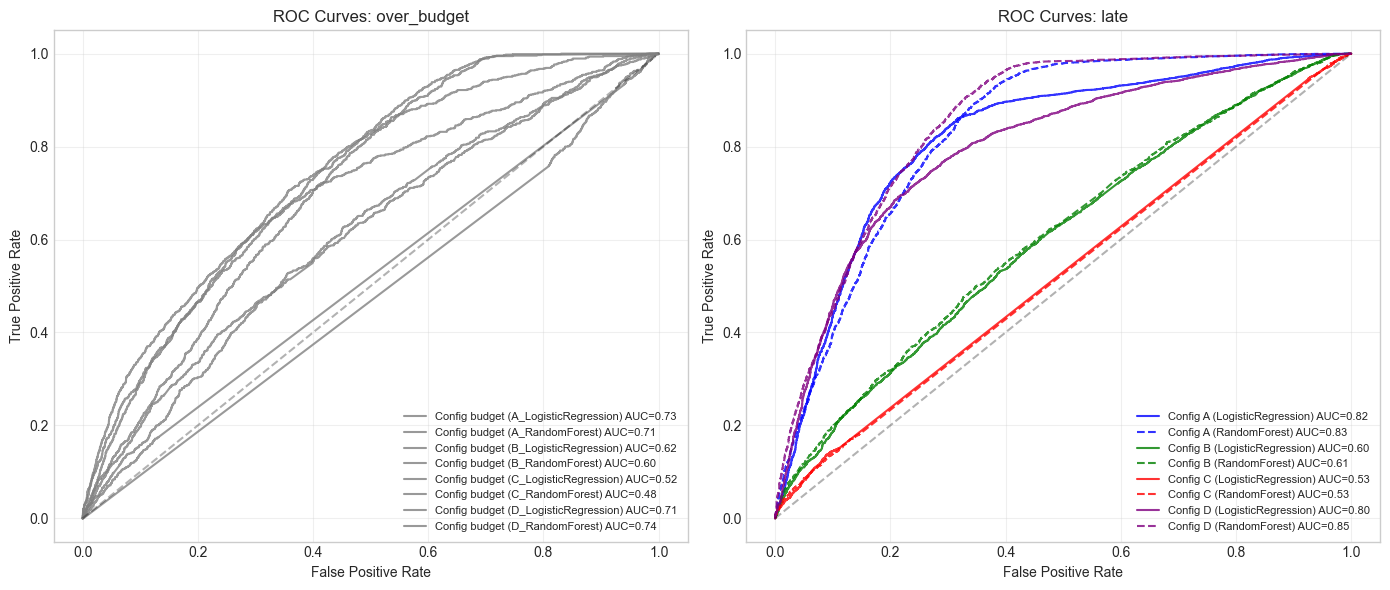

ROC curves saved to: ../figures\roc_curves_comparison.png


In [10]:
# Plot ROC curves for each target
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {'A': 'blue', 'B': 'green', 'C': 'red', 'D': 'purple'}
linestyles = {'LogisticRegression': '-', 'RandomForest': '--'}

for idx, target in enumerate(TARGETS):
    ax = axes[idx]
    
    # Filter models for this target
    target_models = {k: v for k, v in roc_data.items() if k.startswith(target)}
    
    for model_key, roc_info in target_models.items():
        # Parse model key: target_config_algorithm
        parts = model_key.split('_')
        config = parts[1]
        algo = '_'.join(parts[2:])
        
        label = f'Config {config} ({algo}) AUC={roc_info["auc"]:.2f}'
        ax.plot(roc_info['fpr'], roc_info['tpr'], 
                label=label, 
                color=colors.get(config, 'gray'),
                linestyle=linestyles.get(algo, '-'),
                alpha=0.8)
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves: {target}')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
roc_path = os.path.join(FIGURES_DIR, 'roc_curves_comparison.png')
plt.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'ROC curves saved to: {roc_path}')

## 10. Feature Importance (Best RF Models)

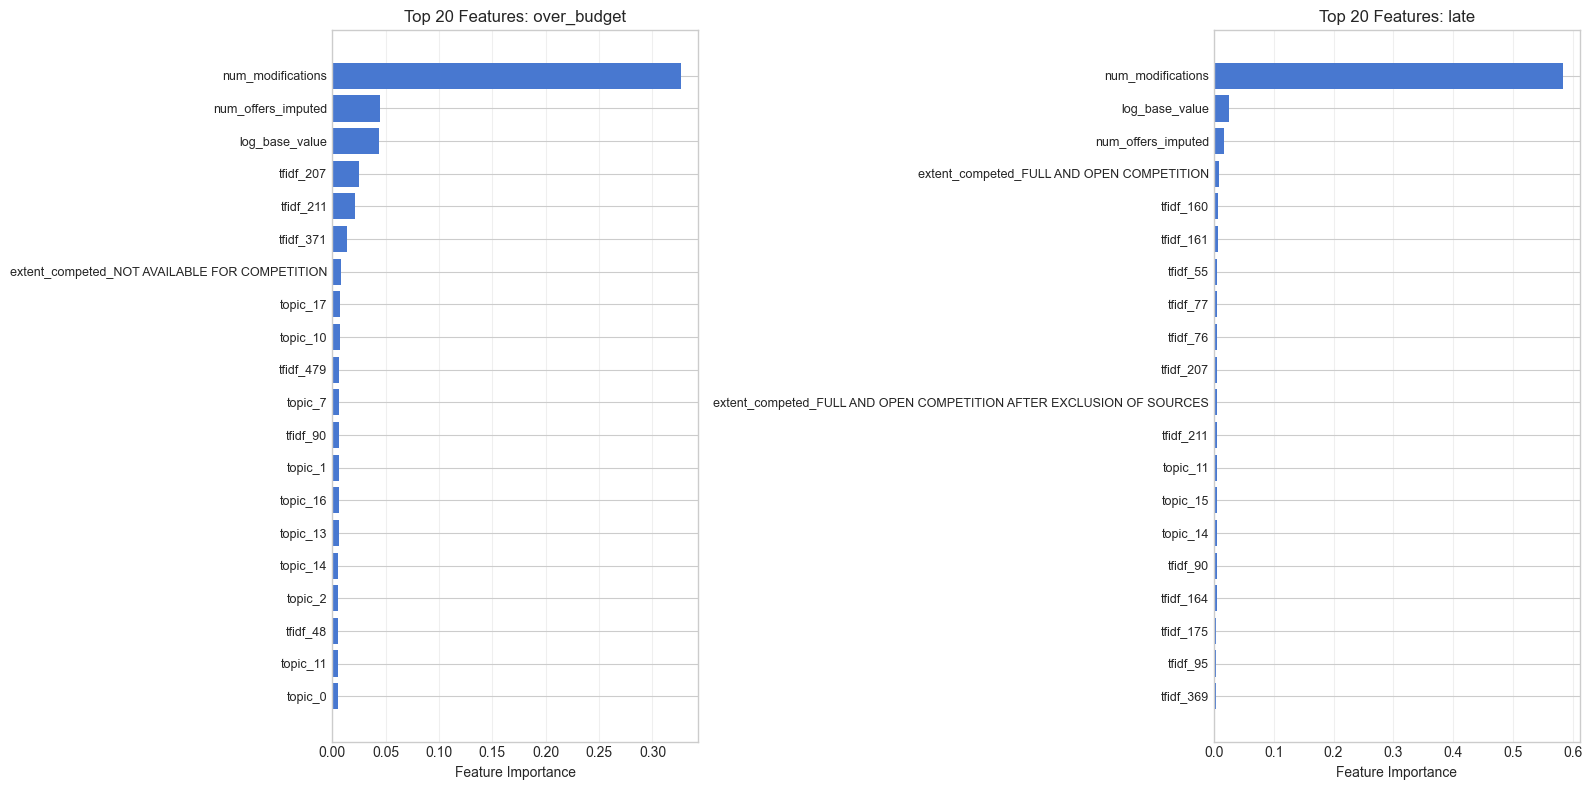

Feature importance saved to: ../figures\feature_importance.png


In [11]:
# Get feature importance from best Random Forest models
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for idx, target in enumerate(TARGETS):
    ax = axes[idx]
    
    # Find best RF model for this target
    rf_models = {k: v for k, v in trained_models.items() 
                  if k.startswith(target) and k.endswith('RandomForest')}
    
    if not rf_models:
        continue
    
    # Get best by config D (combined) if available, otherwise first
    best_key = f'{target}_D_RandomForest'
    if best_key not in rf_models:
        best_key = list(rf_models.keys())[0]
    
    model_info = rf_models[best_key]
    rf_model = model_info['model']
    feature_names = model_info['feature_names']
    
    # Get top 20 features
    importances = rf_model.feature_importances_
    top_idx = np.argsort(importances)[-20:][::-1]
    
    top_features = [feature_names[i] for i in top_idx]
    top_importance = importances[top_idx]
    
    # Plot
    y_pos = np.arange(len(top_features))
    ax.barh(y_pos, top_importance, align='center')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_features, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 20 Features: {target}')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
fi_path = os.path.join(FIGURES_DIR, 'feature_importance.png')
plt.savefig(fi_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Feature importance saved to: {fi_path}')

## 11. Save Trained Models

In [12]:
# Save all trained models
print('Saving trained models...')
saved_models = []

for model_key, model_info in trained_models.items():
    # Create safe filename
    filename = f'{model_key}.pkl'
    filepath = os.path.join(MODELS_DIR, filename)
    
    # Save model and metadata
    save_dict = {
        'model': model_info['model'],
        'scaler': model_info['scaler'],
        'feature_names': model_info['feature_names'],
        'config': model_info['config'],
        'target': model_info['target']
    }
    
    joblib.dump(save_dict, filepath)
    saved_models.append(filename)
    print(f'  Saved: {filename}')

print(f'\nTotal models saved: {len(saved_models)}')

Saving trained models...
  Saved: over_budget_A_LogisticRegression.pkl
  Saved: over_budget_A_RandomForest.pkl
  Saved: over_budget_B_LogisticRegression.pkl
  Saved: over_budget_B_RandomForest.pkl
  Saved: over_budget_C_LogisticRegression.pkl


  Saved: over_budget_C_RandomForest.pkl
  Saved: over_budget_D_LogisticRegression.pkl
  Saved: over_budget_D_RandomForest.pkl
  Saved: late_A_LogisticRegression.pkl


  Saved: late_A_RandomForest.pkl
  Saved: late_B_LogisticRegression.pkl
  Saved: late_B_RandomForest.pkl
  Saved: late_C_LogisticRegression.pkl
  Saved: late_C_RandomForest.pkl
  Saved: late_D_LogisticRegression.pkl
  Saved: late_D_RandomForest.pkl

Total models saved: 16


## 12. Summary

In [13]:
# Final summary
print('=' * 70)
print('PHASE 3 COMPLETE: Classification and Evaluation')
print('=' * 70)

print(f'\nModels Trained: {len(trained_models)}')
print(f'Targets: {TARGETS}')
print(f'Configurations: {list(CONFIGS.keys())}')
print(f'Algorithms: LogisticRegression, RandomForest')

print('\nKey Outputs:')
print(f'  - {RESULTS_PATH}')
print(f'  - {os.path.join(FIGURES_DIR, "roc_curves_comparison.png")}')
print(f'  - {os.path.join(FIGURES_DIR, "feature_importance.png")}')
print(f'  - {MODELS_DIR}/*.pkl ({len(saved_models)} models)')

print('\n' + '=' * 70)
print('Next Steps:')
print('  1. Run 07_gao_validation.ipynb for external validation')
print('  2. Run 08_final_submission.ipynb for master notebook')
print('=' * 70)

PHASE 3 COMPLETE: Classification and Evaluation

Models Trained: 16
Targets: ['over_budget', 'late']
Configurations: ['A', 'B', 'C', 'D']
Algorithms: LogisticRegression, RandomForest

Key Outputs:
  - ../data/processed/results_comparison.csv
  - ../figures\roc_curves_comparison.png
  - ../figures\feature_importance.png
  - ../models/*.pkl (16 models)

Next Steps:
  1. Run 07_gao_validation.ipynb for external validation
  2. Run 08_final_submission.ipynb for master notebook
